# 4. Feasibility evaluation: price-level and return TimeGAN generation

**Question:** do generated sequences match real book structure and temporal behavior?
Removing the initial midpoint reset addresses one failure mode; it is not a complete
realism test. We compare the original price-level baseline and the context-weight-1 return TimeGAN on independent **64-event
unconditional windows**, separately from chapter 3's conditional continuations.

Every run is sampled afresh with seed 0, using its checkpoint's feature representation,
normalization, and noise type. Return windows each start from the saved training median
midpoint; their anchors reset between sequences. Returns and gaps are computed after book
projection **within each sequence**, never across independent windows. The first generated
book has no preceding generated book, so its anchor-to-first return is excluded here.

Training distributions are the generation target. Later same-day validation is a development
comparison, repeatedly inspected in the preceding experiments, not an untouched final test.
Both models generate all 40 features through the TimeGAN decoder. For the return model,
feature zero is a predicted midpoint log return, denormalized and accumulated to recover
prices. No separate model sets the midpoint or fixes expected drift. All changes are in
event time, not fixed clock-time returns.

Previous: [price dynamics experiments](lobster_timegan_return_dynamics.ipynb).


In [1]:
from pathlib import Path
import sys

project_dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'dataset.py').is_file())
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Markdown
from dataset import LOBSTERLevel10Dataset, WindowDataset

torch.set_num_threads(1)

from dataclasses import asdict
from evaluation import book_statistics, compare_sequences, next_step_mae
from predict import generate_features, load_checkpoint

RUNS = {'Baseline': project_dir / 'runs/timegan',
        'TimeGAN returns': project_dir / 'runs/return_price/returns_context_1_moments_10_seed_0'}
N_WINDOWS = 256
SEQUENCE_LENGTH = 64
PREDICTOR_STEPS = 200
SEED = 0
MIDPOINT_BINS = 401
GAP_BINS = 101
PSEUDOCOUNT = 0.5
training = LOBSTERLevel10Dataset(True)
validation = LOBSTERLevel10Dataset(False)
generated_features, generated_books = {}, {}
for label, directory in RUNS.items():
    model, checkpoint = load_checkpoint(directory / 'model.pt')
    if checkpoint['training_config']['sequence_length'] != SEQUENCE_LENGTH:
        raise ValueError('Use the trained window length for each compared model.')
    representation = checkpoint.get('price_representation', 'level')
    data = training if representation == 'level' else LOBSTERLevel10Dataset(True, price_representation=representation)
    if checkpoint['feature_names'] != list(data.feature_names):
        raise ValueError(f'{label}: checkpoint feature names do not match the dataset.')
    np.testing.assert_allclose(checkpoint['feature_mean'].cpu(), data.feature_mean)
    np.testing.assert_allclose(checkpoint['feature_std'].cpu(), data.feature_std)
    torch.manual_seed(SEED)
    features = generate_features(model, N_WINDOWS, SEQUENCE_LENGTH).cpu()
    generated_features[label] = features
    # Return accumulation must restart for each window; never flatten before decoding.
    generated_books[label] = np.stack([
        data.feature_sequence_to_df(window, initial_midpoint=checkpoint.get('reference_midpoint')).to_numpy()
        for window in features])
    print(f'{label}: {N_WINDOWS} × {SEQUENCE_LENGTH} events; midpoint={representation}; noise={model.noise_kind}')

training_books = training.books.to_numpy()[None]
validation_books = validation.books.to_numpy()[None]


Baseline: 256 × 64 events; midpoint=level; noise=wiener_paths


TimeGAN returns: 256 × 64 events; midpoint=return; noise=wiener_increments


## Midpoint log returns and KL divergence

The midpoint is `(best ask + best bid) / 2`; its return is the difference of log midpoints.
Both models and training use the same 401 bins covering the full combined range. Add 0.5
observations per bin before normalizing. The plots and `KL(training || model)` use exactly
these probabilities; natural logs give nats. Bin choice, smoothing, and sample count affect
the estimate. Unequal sample counts are shown explicitly. Zero returns and tails remain in
both KL and the full distribution; the second panel zooms near zero.


,Return observations,Zero-return share,Return mean,Return SD,"KL(training || source), nats"
Source,,,,,
Training,229285,0.895916,-5.141373e-08,0.000034,0.000000
Baseline,16128,0.095734,1.433535e-04,0.000444,1.803733
TimeGAN returns,16128,0.436942,4.065871e-07,0.000023,0.035813


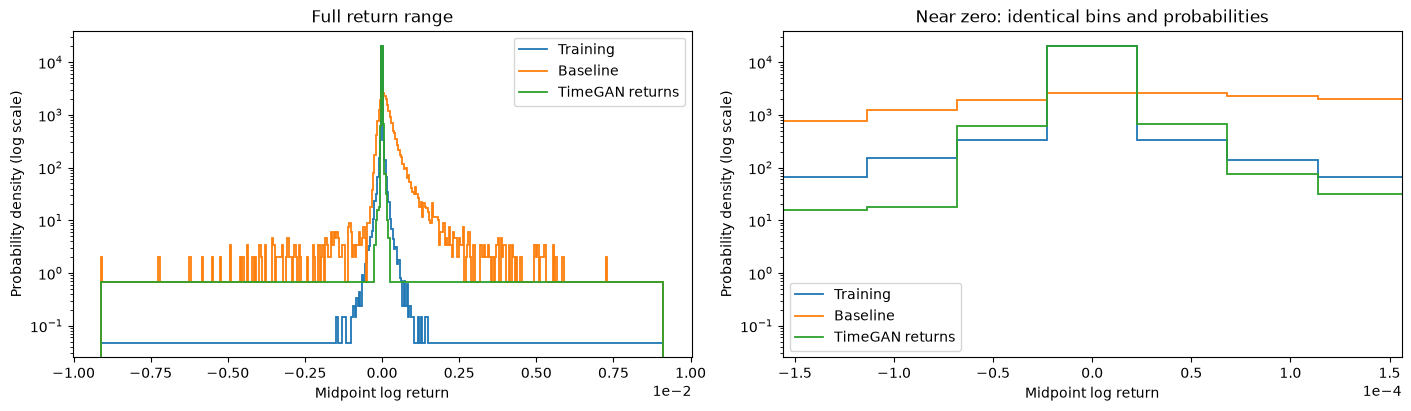

In [2]:
def midpoint_returns(books):
    prices = (books[..., 0] + books[..., 2]) / 20_000
    return np.diff(np.log(prices), axis=1).ravel()

def histogram_probabilities(samples, bins):
    limit = max(np.abs(values).max() for values in samples.values())
    edges = np.linspace(-max(limit, 1e-12), max(limit, 1e-12), bins + 1)
    probabilities = {}
    for label, values in samples.items():
        counts, _ = np.histogram(values, bins=edges)
        probabilities[label] = (counts + PSEUDOCOUNT) / (len(values) + bins * PSEUDOCOUNT)
    return edges, probabilities

returns = {'Training': midpoint_returns(training_books),
           **{label: midpoint_returns(books) for label, books in generated_books.items()}}
edges, probabilities = histogram_probabilities(returns, MIDPOINT_BINS)
return_rows = []
for label, values in returns.items():
    p, q = probabilities['Training'], probabilities[label]
    return_rows.append({'Source': label, 'Return observations': len(values), 'Zero-return share': (values == 0).mean(),
                        'Return mean': values.mean(), 'Return SD': values.std(),
                        'KL(training || source), nats': np.sum(p * np.log(p / q))})
return_summary = pd.DataFrame(return_rows).set_index('Source')
display(return_summary)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax in axes:
    for label, probability in probabilities.items():
        ax.stairs(probability / np.diff(edges), edges, label=label, linewidth=1.3)
    ax.set(yscale='log', xlabel='Midpoint log return', ylabel='Probability density (log scale)')
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
    ax.legend()
axes[0].set_title('Full return range')
zoom = max(np.quantile(np.abs(returns['Training']), 0.99), 2 * np.diff(edges).max())
axes[1].set(title='Near zero: identical bins and probabilities', xlim=(-zoom, zoom))
plt.show()


## Event-to-event changes in adjacent price gaps

For asks, a gap is `ask[level + 1] - ask[level]`; for bids, it is
`bid[level] - bid[level + 1]`. Gap returns are event-to-event changes in the log
of that positive distance. They are different from the gap-level distributions in chapter 1.
The two grids retain all nine gaps on each side, with shared bins across training and both
models in every panel. Integer quote subtraction avoids spurious changes in unchanged gaps.


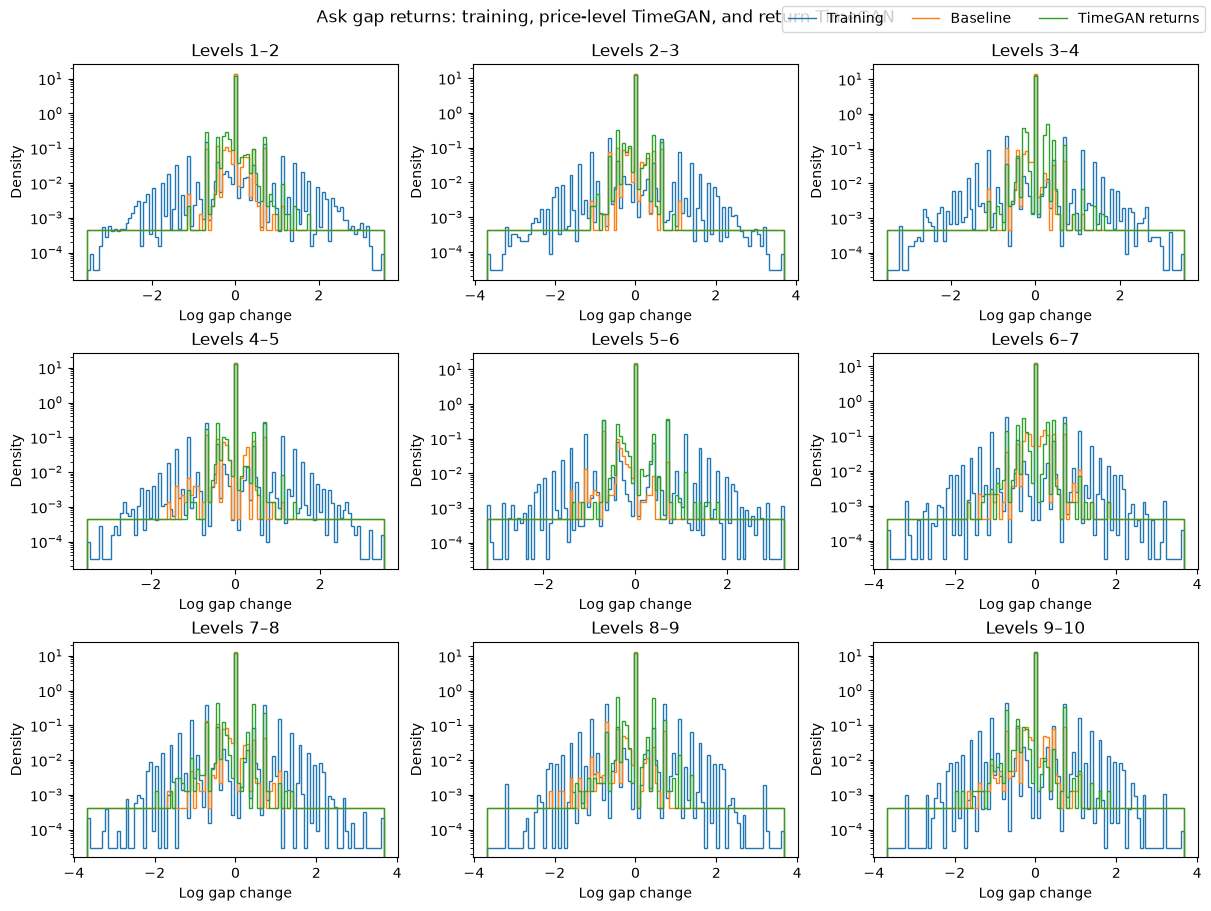

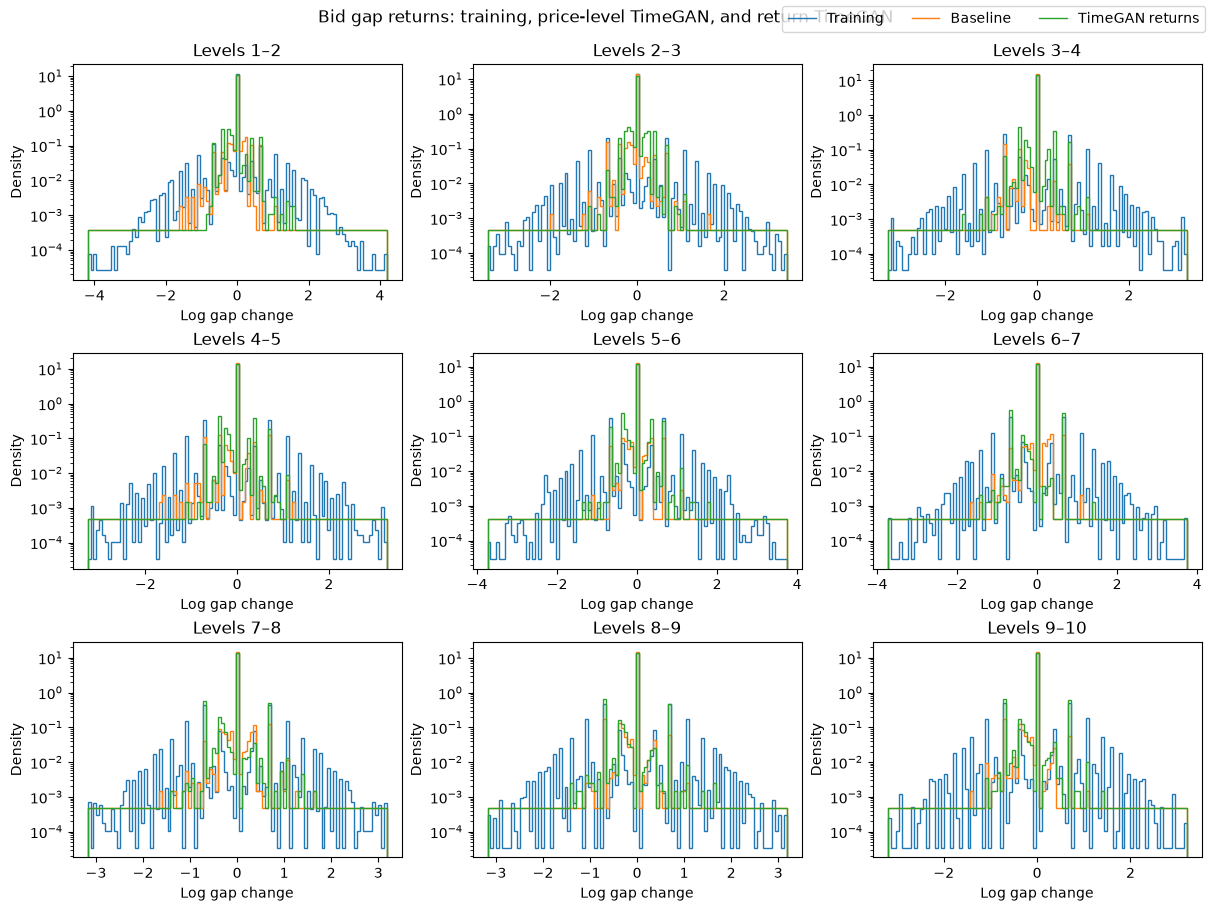

In [3]:
def gap_returns(books, side):
    prices = books[..., 0::4] if side == 'Ask' else books[..., 2::4]
    gaps = np.diff(prices, axis=-1) * (1 if side == 'Ask' else -1)
    if (gaps <= 0).any():
        raise ValueError('Log gap changes require positive gaps.')
    return np.diff(np.log(gaps), axis=1)

for side in ['Ask', 'Bid']:
    changes = {'Training': gap_returns(training_books, side),
               **{label: gap_returns(books, side) for label, books in generated_books.items()}}
    fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout='constrained')
    for index, ax in enumerate(axes.flat):
        samples = {label: values[..., index].ravel() for label, values in changes.items()}
        gap_edges, gap_probability = histogram_probabilities(samples, GAP_BINS)
        for label, probability in gap_probability.items():
            ax.stairs(probability / np.diff(gap_edges), gap_edges, label=label)
        ax.set(title=f'Levels {index + 1}–{index + 2}', yscale='log', xlabel='Log gap change', ylabel='Density')
    fig.legend(*axes.flat[0].get_legend_handles_labels(), loc='outside upper right', ncols=3)
    fig.suptitle(f'{side} gap returns: training, price-level TimeGAN, and return TimeGAN')
    plt.show()


## Spread, depth, and variation in midpoint changes

Equal numbers of nonoverlapping real windows cover training and validation. Generated
windows use the same length. The table reports book statistics in dollars and shares;
these are descriptive comparisons, not claims about out-of-day generalization.
The plots compare spread and total ask/bid depth with the training distribution.
Depth uses a logarithmic share axis so typical values and large generated tails remain visible.
Valid quotes are enforced during projection, so validity is not learned evidence.


,Training,Validation,Baseline,TimeGAN returns
spread_mean_dollars,0.136603,0.097551,0.122887,0.263013
spread_std_dollars,0.053635,0.042699,0.072268,0.115803
ask_depth_mean_shares,1429.320496,1785.302673,2677.409363,2334.278870
ask_depth_std_shares,626.791969,703.186133,1964.822943,25666.330987
bid_depth_mean_shares,1905.154236,2143.455322,3465.512695,3913.993530
bid_depth_std_shares,2626.494266,886.598342,3699.560635,28701.737229
midpoint_change_mean_dollars,0.000066,-0.000013,0.032154,0.000091
midpoint_change_std_dollars,0.006733,0.005473,0.099389,0.005066
midpoint_lag1_correlation,0.999986,0.999533,0.996323,0.994311


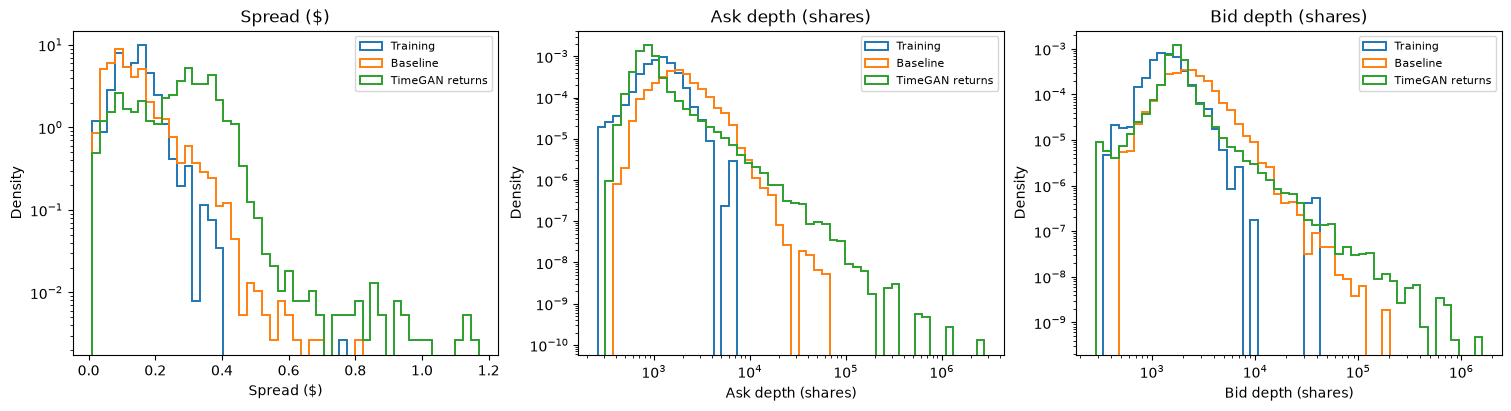

In [4]:
def select_windows(data):
    windows = WindowDataset(data.features, SEQUENCE_LENGTH, stride=SEQUENCE_LENGTH)
    indices = np.linspace(0, len(windows) - 1, min(N_WINDOWS, len(windows))).round().astype(int)
    features = torch.stack([windows[int(index)] for index in indices])
    books = np.stack([data.books.iloc[index * SEQUENCE_LENGTH:(index + 1) * SEQUENCE_LENGTH].to_numpy()
                      for index in indices])
    return features, books

real_training, sampled_training_books = select_windows(training)
real_validation, sampled_validation_books = select_windows(validation)
book_sources = {'Training': sampled_training_books, 'Validation': sampled_validation_books, **generated_books}
book_summary = pd.DataFrame({label: asdict(book_statistics(torch.from_numpy(books)))
                             for label, books in book_sources.items()})
display(book_summary)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
for ax, quantity in zip(axes, ['Spread ($)', 'Ask depth (shares)', 'Bid depth (shares)']):
    values = {}
    for label, books in {'Training': sampled_training_books, **generated_books}.items():
        if quantity == 'Spread ($)':
            values[label] = ((books[..., 0] - books[..., 2]) / 10_000).ravel()
        else:
            start = 1 if quantity.startswith('Ask') else 3
            values[label] = books[..., start::4].sum(axis=-1).ravel()
    combined = np.concatenate(list(values.values()))
    if quantity == 'Spread ($)':
        bins = np.histogram_bin_edges(combined, bins=50)
    else:
        bins = np.geomspace(max(1, combined.min()), combined.max() * 1.0001, 51)
        ax.set_xscale('log')
    for label, sample in values.items():
        ax.hist(sample, bins=bins, density=True, histtype='step', linewidth=1.4, label=label)
    ax.set(title=quantity, xlabel=quantity, ylabel='Density', yscale='log')
    ax.legend(fontsize=8)
plt.show()


## Temporal and joint structure, before projection

The midpoint's representation differs between models, so compare the **other 39 features**
in their common training-standardized units. Errors below average feature means, SDs,
change SDs, lag-one correlations, cross-feature correlations, and between-window variation.
Each model is compared separately with training and validation. Smaller errors mean closer
agreement; no single statistic establishes realism. Midpoint level autocorrelation can look
high for a drifting path, so also report lag-one correlation of **midpoint returns**.


In [5]:
structure_rows = []
for label, features in generated_features.items():
    for reference, real in [('Training', real_training), ('Validation', real_validation)]:
        errors = compare_sequences(real[..., 1:], features[..., 1:]).absolute_errors
        structure_rows.append({'Model': label, 'Reference': reference,
                               'Mean error': float(errors.mean), 'SD error': float(errors.std),
                               'Change SD error': float(errors.change_std),
                               'Lag-one correlation error': float(errors.lag1_correlation),
                               'Cross-feature correlation error': float(errors.feature_correlation),
                               'Between-window variation error': float(errors.window_mean_std)})
structure_summary = pd.DataFrame(structure_rows).set_index(['Model', 'Reference'])
display(structure_summary.round(4))

return_dependence = []
for label, books in book_sources.items():
    prices = (books[..., 0] + books[..., 2]) / 20_000
    changes = np.diff(np.log(prices), axis=1)
    x, y = changes[:, :-1].ravel(), changes[:, 1:].ravel()
    correlation = np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0
    return_dependence.append({'Source': label, 'Midpoint return lag-one correlation': correlation})
display(pd.DataFrame(return_dependence).set_index('Source').round(4))


Mean error  SD error  Change SD error  \
Model           Reference                                           
Baseline        Training        0.4850    0.2031           0.3752   
                Validation      0.4825    0.3683           0.2571   
TimeGAN returns Training        0.5445    0.2010           0.3040   
                Validation      0.6215    0.1320           0.1858   

                            Lag-one correlation error  \
Model           Reference                               
Baseline        Training                       0.1216   
                Validation                     0.1033   
TimeGAN returns Training                       0.0993   
                Validation                     0.0810   

                            Cross-feature correlation error  \
Model           Reference                                     
Baseline        Training                             0.1129   
                Validation                           0.1300   
TimeGAN returns Training                             0.1674   
                Validation                           0.1850   

                            Between-window variation error  
Model           Reference                                   
Baseline        Training                            0.3983  
                Validation                          0.5077  
TimeGAN returns Training                            0.3786  
                Validation                          0.2692

,Midpoint return lag-one correlation
Source,
Training,-0.1213
Validation,-0.2813
Baseline,0.6363
TimeGAN returns,-0.2847


## Does synthetic book structure support next-event prediction?

Reuse the project's small GRU predictor with identical seed, initialization, sampling,
and 200 updates. Train one on real training windows and one on each model's synthetic
windows, then score all on the same real validation windows. Restrict this comparison to
the common 39 structure features so a log price is never compared with a log return.
The reported MAE is in their training-standardized units; this is a limited structure
utility check, not a midpoint forecasting benchmark or a fully tuned downstream model.


In [6]:
predictor_rows = []
for label, features in {'Real training': real_training, **generated_features}.items():
    score = next_step_mae(features[..., 1:], real_validation[..., 1:], steps=PREDICTOR_STEPS, seed=SEED)
    predictor_rows.append({'Predictor training source': label, 'Validation MAE, common 39 features': score})
predictor_summary = pd.DataFrame(predictor_rows).set_index('Predictor training source')
display(predictor_summary.round(4))


,"Validation MAE, common 39 features"
Predictor training source,
Real training,0.6224
Baseline,0.6836
TimeGAN returns,0.7138


In [7]:
baseline = return_summary.loc['Baseline']
returns_model = return_summary.loc['TimeGAN returns']
real_score = predictor_summary.loc['Real training'].iloc[0]
base_score = predictor_summary.loc['Baseline'].iloc[0]
return_score = predictor_summary.loc['TimeGAN returns'].iloc[0]
price_finding = ('The return TimeGAN has lower midpoint histogram divergence in this comparison.'
                 if returns_model['KL(training || source), nats'] < baseline['KL(training || source), nats']
                 else 'The return TimeGAN does not have lower midpoint histogram divergence in this comparison.')
structure_finding = ('The predictor trained on return-TimeGAN windows performs worse than the baseline-trained predictor under this budget.'
                     if return_score > base_score else
                     'The predictor trained on return-TimeGAN windows performs at least as well as the baseline-trained predictor under this budget.')
display(Markdown(f"""
## Measured outcome and limits

The midpoint histogram KL is **{baseline['KL(training || source), nats']:.3f} nats** for the
price-level baseline and **{returns_model['KL(training || source), nats']:.3f} nats** for the
return TimeGAN under the shared bins used here. Real training returns are exactly zero in
**{return_summary.loc['Training', 'Zero-return share']:.1%}** of events, compared with
**{baseline['Zero-return share']:.1%}** for the baseline and **{returns_model['Zero-return share']:.1%}**
for the return TimeGAN. Inspect tails and the gap, spread, depth, and temporal comparisons alongside KL.

The common-feature validation predictor MAE is **{real_score:.3f}** when trained on real
windows, **{base_score:.3f}** on baseline windows, and **{return_score:.3f}** on return-TimeGAN
windows, using equal budgets. {price_finding} {structure_finding}
These scores describe the small predictor experiment rather than a general utility guarantee.

Every generated feature comes from TimeGAN's decoder. Midpoint returns are accumulated
without an external correction or imposed drift; a remaining return bias is a generation
error that can compound in long continuations. This study contains one AMZN day and one
training seed per variant, with validation used throughout development. Additional days,
repeated seeds, and conditional uncertainty checks are needed before extending its
feasibility conclusions beyond these experiments.
"""))



## Measured outcome and limits

The midpoint histogram KL is **1.804 nats** for the
price-level baseline and **0.036 nats** for the
return TimeGAN under the shared bins used here. Real training returns are exactly zero in
**89.6%** of events, compared with
**9.6%** for the baseline and **43.7%**
for the return TimeGAN. Inspect tails and the gap, spread, depth, and temporal comparisons alongside KL.

The common-feature validation predictor MAE is **0.622** when trained on real
windows, **0.684** on baseline windows, and **0.714** on return-TimeGAN
windows, using equal budgets. The return TimeGAN has lower midpoint histogram divergence in this comparison. The predictor trained on return-TimeGAN windows performs worse than the baseline-trained predictor under this budget.
These scores describe the small predictor experiment rather than a general utility guarantee.

Every generated feature comes from TimeGAN's decoder. Midpoint returns are accumulated
without an external correction or imposed drift; a remaining return bias is a generation
error that can compound in long continuations. This study contains one AMZN day and one
training seed per variant, with validation used throughout development. Additional days,
repeated seeds, and conditional uncertainty checks are needed before extending its
feasibility conclusions beyond these experiments.
